In [6]:
import freetype

font_file = "../fonts/字悦九叠印篆.ttf"
face = freetype.Face(font_file)
face.load_char("爽", freetype.FT_LOAD_NO_SCALE | freetype.FT_LOAD_NO_HINTING)

outline = face.glyph.outline

In [7]:
outline.points

[(45, -4),
 (420, -4),
 (420, 68),
 (45, 68),
 (45, 211),
 (422, 211),
 (473, 262),
 (473, 711),
 (45, 711),
 (45, 746),
 (473, 746),
 (473, 782),
 (509, 782),
 (509, 746),
 (938, 746),
 (938, 711),
 (509, 711),
 (509, 262),
 (560, 211),
 (938, 211),
 (938, 68),
 (563, 68),
 (563, -4),
 (938, -4),
 (938, -146),
 (527, -146),
 (527, -111),
 (902, -111),
 (902, -39),
 (527, -39),
 (527, 104),
 (902, 104),
 (902, 175),
 (546, 175),
 (491, 230),
 (436, 175),
 (80, 175),
 (80, 104),
 (455, 104),
 (455, -39),
 (80, -39),
 (80, -111),
 (455, -111),
 (455, -146),
 (45, -146),
 (45, 318),
 (170, 318),
 (199, 354),
 (170, 389),
 (45, 389),
 (45, 425),
 (187, 425),
 (223, 382),
 (258, 425),
 (402, 425),
 (402, 389),
 (275, 389),
 (246, 354),
 (275, 318),
 (402, 318),
 (402, 282),
 (258, 282),
 (223, 325),
 (187, 282),
 (45, 282),
 (45, 532),
 (170, 532),
 (199, 568),
 (170, 603),
 (45, 603),
 (45, 639),
 (187, 639),
 (223, 596),
 (258, 639),
 (402, 639),
 (402, 603),
 (275, 603),
 (246, 568),
 (2

In [4]:
outline.tags

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

In [5]:
outline.contours

[44, 64, 84, 104, 124]

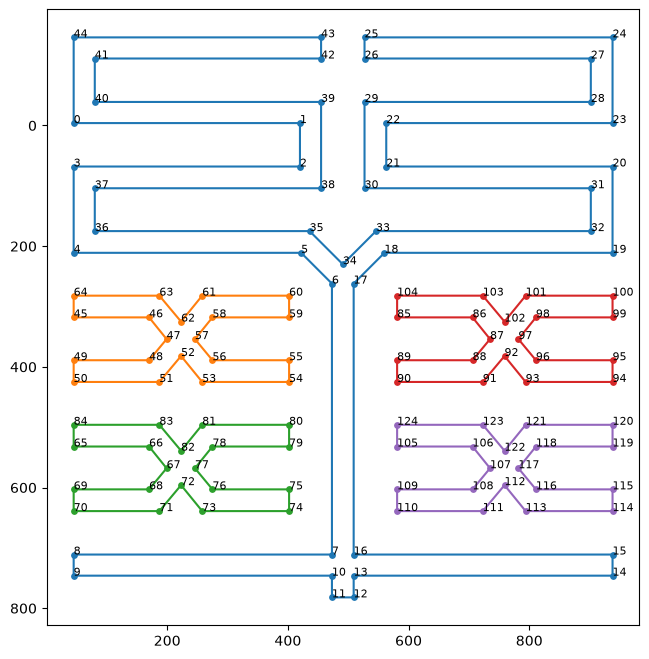

In [ ]:
import matplotlib.pyplot as plt

points = outline.points
contours = outline.contours


def draw(points, contours):
    fig, ax = plt.subplots(figsize=(8, 8))

    start = 0

    for end in contours:
        contour = points[start : end + 1]

        x = [p[0] for p in contour]
        y = [p[1] for p in contour]

        # 闭合
        x.append(contour[0][0])
        y.append(contour[0][1])

        ax.plot(x, y, "-")
        ax.scatter(x[:-1], y[:-1], s=15)

        # 标注点编号（可选）
        for idx, p in enumerate(contour, start):
            ax.text(p[0], p[1], str(idx), fontsize=8)

        start = end + 1

    ax.set_aspect("equal")
    ax.invert_yaxis()
    plt.show()


draw(points, contours)

In [99]:
def compute_edges(points, contours):
    edges = {}

    start = 0

    for end in contours:
        # 当前轮廓的所有点索引
        indices = list(range(start, end + 1))

        # 相邻点
        for i in range(len(indices)):
            idx1 = indices[i]
            idx2 = indices[(i + 1) % len(indices)]  # 最后一个自动连回第一个

            x1, y1 = points[idx1]
            x2, y2 = points[idx2]

            edges[(idx1, idx2)] = ((x2 - x1), (y2 - y1))

        start = end + 1
    return edges


edges = compute_edges(points, contours)
print(edges)

{(0, 1): (375, 0), (1, 2): (0, 72), (2, 3): (-375, 0), (3, 4): (0, 143), (4, 5): (377, 0), (5, 6): (51, 51), (6, 7): (0, 449), (7, 8): (-428, 0), (8, 9): (0, 35), (9, 10): (428, 0), (10, 11): (0, 36), (11, 12): (36, 0), (12, 13): (0, -36), (13, 14): (429, 0), (14, 15): (0, -35), (15, 16): (-429, 0), (16, 17): (0, -449), (17, 18): (51, -51), (18, 19): (378, 0), (19, 20): (0, -143), (20, 21): (-375, 0), (21, 22): (0, -72), (22, 23): (375, 0), (23, 24): (0, -142), (24, 25): (-411, 0), (25, 26): (0, 35), (26, 27): (375, 0), (27, 28): (0, 72), (28, 29): (-375, 0), (29, 30): (0, 143), (30, 31): (375, 0), (31, 32): (0, 71), (32, 33): (-356, 0), (33, 34): (-55, 55), (34, 35): (-55, -55), (35, 36): (-356, 0), (36, 37): (0, -71), (37, 38): (375, 0), (38, 39): (0, -143), (39, 40): (-375, 0), (40, 41): (0, -72), (41, 42): (375, 0), (42, 43): (0, -35), (43, 44): (-410, 0), (44, 0): (0, 142), (45, 46): (125, 0), (46, 47): (29, 36), (47, 48): (-29, 35), (48, 49): (-125, 0), (49, 50): (0, 36), (50, 51

In [80]:
import numpy as np

In [118]:
def smod(x, n):
    return ((x + n / 2) % n) - n / 2

In [129]:
def compute_gcd(edges):
    ds = []
    for dx, dy in edges.values():
        ds.extend([dx, dy])
    ds = np.asarray(ds)
    v_s, n_s = np.unique(ds[ds != 0], return_counts=True)
    gcd_candidate = v_s[n_s.argmax()]
    gcds = np.arange(gcd_candidate // 2 - 5, gcd_candidate // 2 + 5 + 1)
    loss = np.zeros_like(gcds)
    for i, d in enumerate(gcds):
        loss[i] = np.sum(np.abs(smod(v_s, d)) * n_s)
    gcd = gcds[loss.argmin()].item()
    return gcd, v_s, n_s, loss

In [130]:
gcd, v_s, n_s, loss = compute_gcd(edges)

In [131]:
loss

array([ 487,  572,  716,  588,  652,  364,  842,  832,  822, 1114, 1236])

In [132]:
loss = np.sum(np.abs(smod(v_s, 18)) * n_s)
loss

np.float64(364.0)

In [19]:
xs = []
ys = []
for point in points:
    x, y = point
    xs.append(x)
    ys.append(y)
xs.sort()
ys.sort()
x_diff = np.diff(xs)
y_diff = np.diff(ys)

In [31]:
v_x, n_x = np.unique(x_diff[x_diff != 0], return_counts=True)
v_y, n_y = np.unique(y_diff[y_diff != 0], return_counts=True)

In [32]:
print(v_x)
print(n_x)
print(v_y)
print(n_y)

[  2   3  12  14  17  18  19  23  24  35  36  90  91 125 127]
[1 1 4 2 4 6 2 2 2 1 1 1 1 1 1]
[ 7 19 20 28 29 32 35 36 71 72]
[4 1 1 2 2 1 3 7 2 3]


In [ ]:
gcd, _, _, _ = compute_gcd(edges)

In [ ]:
def sdivide(x, n):
    k = round(x / n)
    return k * n

In [133]:
gcd = 18

In [134]:
# calibrate edges
calibrated_edges = {}
for pair, edge in edges.items():
    dx, dy = edge
    calibrated_edges[pair] = (sdivide(dx, gcd), sdivide(dy, gcd))

In [135]:
edges

{(0, 1): (375, 0),
 (1, 2): (0, 72),
 (2, 3): (-375, 0),
 (3, 4): (0, 143),
 (4, 5): (377, 0),
 (5, 6): (51, 51),
 (6, 7): (0, 449),
 (7, 8): (-428, 0),
 (8, 9): (0, 35),
 (9, 10): (428, 0),
 (10, 11): (0, 36),
 (11, 12): (36, 0),
 (12, 13): (0, -36),
 (13, 14): (429, 0),
 (14, 15): (0, -35),
 (15, 16): (-429, 0),
 (16, 17): (0, -449),
 (17, 18): (51, -51),
 (18, 19): (378, 0),
 (19, 20): (0, -143),
 (20, 21): (-375, 0),
 (21, 22): (0, -72),
 (22, 23): (375, 0),
 (23, 24): (0, -142),
 (24, 25): (-411, 0),
 (25, 26): (0, 35),
 (26, 27): (375, 0),
 (27, 28): (0, 72),
 (28, 29): (-375, 0),
 (29, 30): (0, 143),
 (30, 31): (375, 0),
 (31, 32): (0, 71),
 (32, 33): (-356, 0),
 (33, 34): (-55, 55),
 (34, 35): (-55, -55),
 (35, 36): (-356, 0),
 (36, 37): (0, -71),
 (37, 38): (375, 0),
 (38, 39): (0, -143),
 (39, 40): (-375, 0),
 (40, 41): (0, -72),
 (41, 42): (375, 0),
 (42, 43): (0, -35),
 (43, 44): (-410, 0),
 (44, 0): (0, 142),
 (45, 46): (125, 0),
 (46, 47): (29, 36),
 (47, 48): (-29, 35),


In [136]:
for pair, edge in edges.items():
    print(pair, edge, calibrated_edges[pair])

(0, 1) (375, 0) (378, 0)
(1, 2) (0, 72) (0, 72)
(2, 3) (-375, 0) (-378, 0)
(3, 4) (0, 143) (0, 144)
(4, 5) (377, 0) (378, 0)
(5, 6) (51, 51) (54, 54)
(6, 7) (0, 449) (0, 450)
(7, 8) (-428, 0) (-432, 0)
(8, 9) (0, 35) (0, 36)
(9, 10) (428, 0) (432, 0)
(10, 11) (0, 36) (0, 36)
(11, 12) (36, 0) (36, 0)
(12, 13) (0, -36) (0, -36)
(13, 14) (429, 0) (432, 0)
(14, 15) (0, -35) (0, -36)
(15, 16) (-429, 0) (-432, 0)
(16, 17) (0, -449) (0, -450)
(17, 18) (51, -51) (54, -54)
(18, 19) (378, 0) (378, 0)
(19, 20) (0, -143) (0, -144)
(20, 21) (-375, 0) (-378, 0)
(21, 22) (0, -72) (0, -72)
(22, 23) (375, 0) (378, 0)
(23, 24) (0, -142) (0, -144)
(24, 25) (-411, 0) (-414, 0)
(25, 26) (0, 35) (0, 36)
(26, 27) (375, 0) (378, 0)
(27, 28) (0, 72) (0, 72)
(28, 29) (-375, 0) (-378, 0)
(29, 30) (0, 143) (0, 144)
(30, 31) (375, 0) (378, 0)
(31, 32) (0, 71) (0, 72)
(32, 33) (-356, 0) (-360, 0)
(33, 34) (-55, 55) (-54, 54)
(34, 35) (-55, -55) (-54, -54)
(35, 36) (-356, 0) (-360, 0)
(36, 37) (0, -71) (0, -72)
(37,

In [137]:
# coordinate calibration
offset = points[0]
calibrated_points = [(0, 0)]
is_start_of_contour = False
for pair, edge in calibrated_edges.items():
    i, j = pair
    if is_start_of_contour:
        x, y = points[i]
        x_ = sdivide(x - offset[0], gcd)
        y_ = sdivide(y - offset[1], gcd)
        calibrated_points.append((x_, y_))
        is_start_of_contour = False
    if i < j:
        x, y = calibrated_points[i]
        dx, dy = edge
        calibrated_points.append((x + dx, y + dy))
    else:
        is_start_of_contour = True

In [138]:
calibrated_points

[(0, 0),
 (378, 0),
 (378, 72),
 (0, 72),
 (0, 216),
 (378, 216),
 (432, 270),
 (432, 720),
 (0, 720),
 (0, 756),
 (432, 756),
 (432, 792),
 (468, 792),
 (468, 756),
 (900, 756),
 (900, 720),
 (468, 720),
 (468, 270),
 (522, 216),
 (900, 216),
 (900, 72),
 (522, 72),
 (522, 0),
 (900, 0),
 (900, -144),
 (486, -144),
 (486, -108),
 (864, -108),
 (864, -36),
 (486, -36),
 (486, 108),
 (864, 108),
 (864, 180),
 (504, 180),
 (450, 234),
 (396, 180),
 (36, 180),
 (36, 108),
 (414, 108),
 (414, -36),
 (36, -36),
 (36, -108),
 (414, -108),
 (414, -144),
 (0, -144),
 (0, 324),
 (126, 324),
 (162, 360),
 (126, 396),
 (0, 396),
 (0, 432),
 (144, 432),
 (180, 396),
 (216, 432),
 (360, 432),
 (360, 396),
 (234, 396),
 (198, 360),
 (234, 324),
 (360, 324),
 (360, 288),
 (216, 288),
 (180, 324),
 (144, 288),
 (0, 288),
 (0, 540),
 (126, 540),
 (162, 576),
 (126, 612),
 (0, 612),
 (0, 648),
 (144, 648),
 (180, 612),
 (216, 648),
 (360, 648),
 (360, 612),
 (234, 612),
 (198, 576),
 (234, 540),
 (360, 

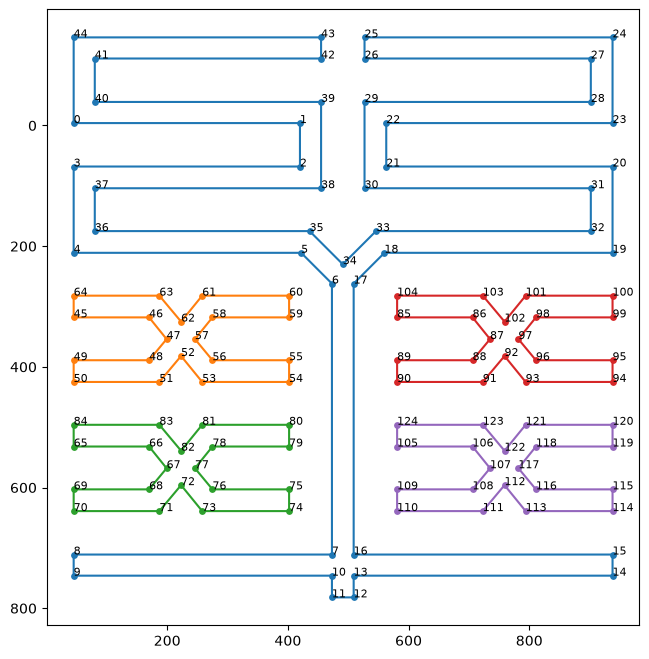

In [139]:
draw(points, contours)

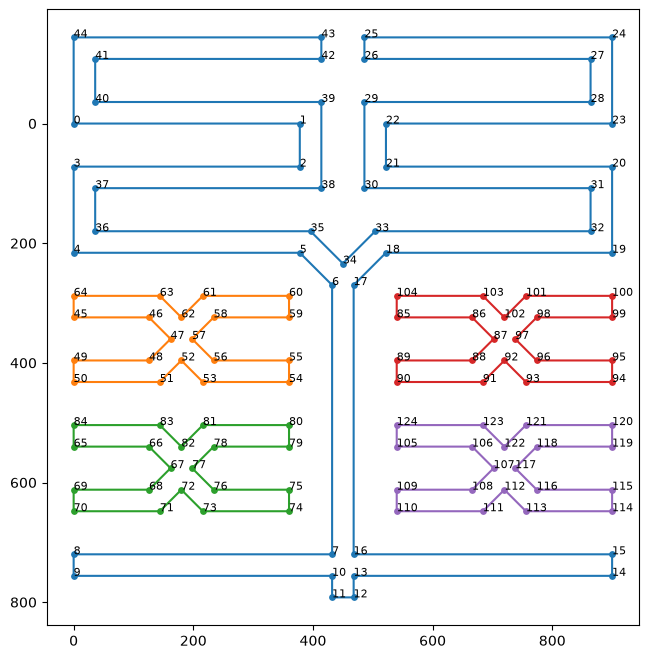

In [140]:
draw(calibrated_points, contours)